In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# CSV load karo (apna exported file ka naam/path daalo)
df = pd.read_csv("D:/SUBJECTS/Data_Analyst/AnalystProjects/AQI_Analysis/city_day_cleaned.csv")

df['Date'] = pd.to_datetime(df['Date'])
df.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [4]:
print(df.shape)          # kitni rows, columns
print(df.isnull().sum()) # kaunse columns mein kitni missing values
print(df['City'].unique())  # saari cities list

(29531, 16)
City              0
Date              0
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
dtype: int64
['Ahmedabad' 'Aizawl' 'Amaravati' 'Amritsar' 'Bengaluru' 'Bhopal'
 'Brajrajnagar' 'Chandigarh' 'Chennai' 'Coimbatore' 'Delhi' 'Ernakulam'
 'Gurugram' 'Guwahati' 'Hyderabad' 'Jaipur' 'Jorapokhar' 'Kochi' 'Kolkata'
 'Lucknow' 'Mumbai' 'Patna' 'Shillong' 'Talcher' 'Thiruvananthapuram'
 'Visakhapatnam']


In [5]:
selected_cities = ['Delhi', 'Mumbai', 'Bengaluru', 'Kolkata', 'Bhopal', 
                    'Lucknow', 'Chennai', 'Patna', 'Hyderabad', 'Jaipur']

df = df[df['City'].isin(selected_cities)]
print(df.shape)
print(df['City'].unique())

(16126, 16)
['Bengaluru' 'Bhopal' 'Chennai' 'Delhi' 'Hyderabad' 'Jaipur' 'Kolkata'
 'Lucknow' 'Mumbai' 'Patna']


In [8]:

# pollutant columns - fill city-wise interpolation
pollutant_cols = ['PM2.5','PM10','NO','NO2','NOx','NH3','CO','SO2','O3','Benzene','Toluene']

df = df.sort_values(['City','Date'])
for col in pollutant_cols:
    df[col] = df.groupby('City')[col].transform(
        lambda x: x.interpolate(method='linear').bfill().ffill()
    )

print(df.isnull().sum())
print(df.shape)

City             0
Date             0
PM2.5            0
PM10          1893
NO               0
NO2              0
NOx              0
NH3              0
CO               0
SO2              0
O3               0
Benzene        278
Toluene       1053
AQI              0
AQI_Bucket       0
dtype: int64
(13926, 15)


In [9]:
df[df['PM10'].isnull()]['City'].value_counts()
df[df['Benzene'].isnull()]['City'].value_counts()
df[df['Toluene'].isnull()]['City'].value_counts()

City
Mumbai    775
Bhopal    278
Name: count, dtype: int64

In [10]:
for col in ['PM10', 'Benzene', 'Toluene']:
    df[col] = df[col].fillna(df[col].median())

print(df.isnull().sum())

City          0
Date          0
PM2.5         0
PM10          0
NO            0
NO2           0
NOx           0
NH3           0
CO            0
SO2           0
O3            0
Benzene       0
Toluene       0
AQI           0
AQI_Bucket    0
dtype: int64


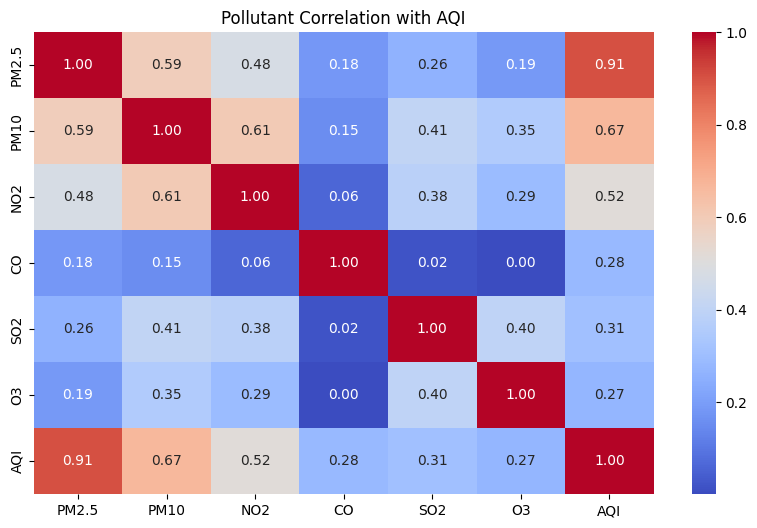

In [11]:
#Correlation - which pollutant Drive AQI
plt.figure(figsize=(10,6))
corr_matrix = df[['PM2.5','PM10','NO2','CO','SO2','O3','AQI']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Pollutant Correlation with AQI')
plt.show()

In [12]:
# city wise dominant Pollutant 
for city in selected_cities:
    city_data = df[df['City']==city]
    corr = city_data[['PM2.5','PM10','NO2','CO','SO2','O3']].corrwith(city_data['AQI'])
    top_pollutant = corr.idxmax()
    print(f"{city}: dominant pollutant = {top_pollutant} (corr = {corr.max():.2f})")

Delhi: dominant pollutant = PM2.5 (corr = 0.88)
Mumbai: dominant pollutant = PM2.5 (corr = 0.94)
Bengaluru: dominant pollutant = PM10 (corr = 0.46)
Kolkata: dominant pollutant = PM10 (corr = 0.97)
Bhopal: dominant pollutant = PM2.5 (corr = 0.90)
Lucknow: dominant pollutant = PM2.5 (corr = 0.92)
Chennai: dominant pollutant = PM2.5 (corr = 0.69)
Patna: dominant pollutant = PM2.5 (corr = 0.92)
Hyderabad: dominant pollutant = PM2.5 (corr = 0.80)
Jaipur: dominant pollutant = PM2.5 (corr = 0.85)


00:18:24 - cmdstanpy - INFO - Chain [1] start processing
00:18:24 - cmdstanpy - INFO - Chain [1] done processing


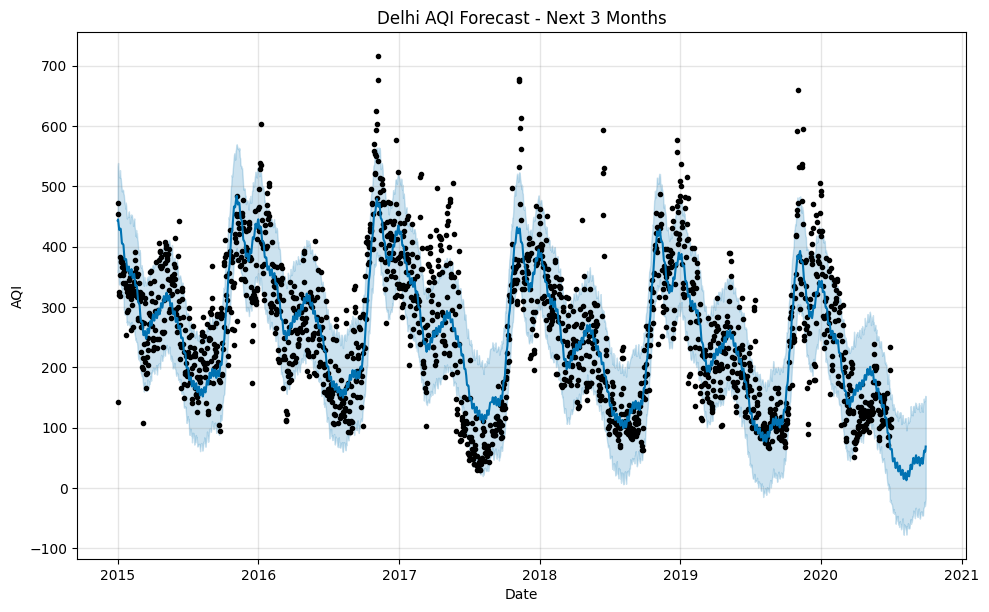

In [17]:
from prophet import Prophet

# Step 1: choose city and prepare the data
city_name = 'Delhi'
city_df = df[df['City']==city_name][['Date','AQI']].copy()
city_df.columns = ['ds','y']   # Prophet ko exactly ye naam chahiye
city_df = city_df.sort_values('ds')

# Step 2: create model and train 
model = Prophet(yearly_seasonality=True, daily_seasonality=False)
model.fit(city_df)

# Step 3: Future dates create  and predict 
future = model.make_future_dataframe(periods=90)
forecast = model.predict(future)

# Step 4: Plot 
fig1 = model.plot(forecast)
plt.title(f'{city_name} AQI Forecast - Next 3 Months')
plt.xlabel('Date')
plt.ylabel('AQI')
plt.show()

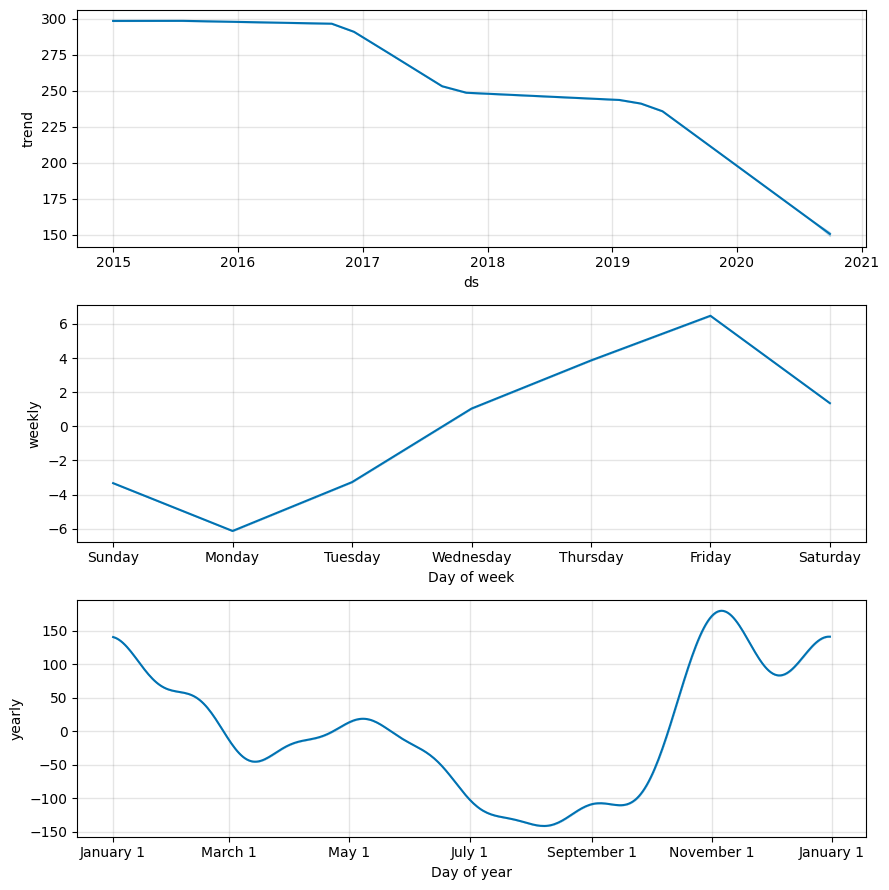

In [18]:
# Shows overall trend + yearly seasonality pattern
fig2 = model.plot_components(forecast)
plt.show()

In [19]:
# Show last 10 predicted values (next few days of forecast)
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(10)

,ds,yhat,yhat_lower,yhat_upper
2079,2020-09-20,41.287216,-46.014419,130.857169
2080,2020-09-21,39.796437,-45.538197,126.070534
2081,2020-09-22,44.355885,-45.895154,136.708355
2082,2020-09-23,50.768905,-34.208382,141.027941
2083,2020-09-24,56.118664,-32.406630,147.976429
2084,2020-09-25,61.710397,-30.623255,143.454040
2085,2020-09-26,60.011737,-22.915067,144.434356
2086,2020-09-27,59.214662,-30.103613,144.484149
2087,2020-09-28,60.771547,-26.492854,152.492263
2088,2020-09-29,68.466338,-17.913221,151.434430


In [20]:
from sklearn.metrics import mean_absolute_error

# Compare actual vs predicted for historical dates (where we have real data)
actual_vs_pred = forecast[forecast['ds'].isin(city_df['ds'])][['ds','yhat']]
merged = city_df.merge(actual_vs_pred, on='ds')

mae = mean_absolute_error(merged['y'], merged['yhat'])
print(f"Mean Absolute Error: {mae:.2f} AQI points")

Mean Absolute Error: 52.84 AQI points


00:21:02 - cmdstanpy - INFO - Chain [1] start processing
00:21:02 - cmdstanpy - INFO - Chain [1] done processing


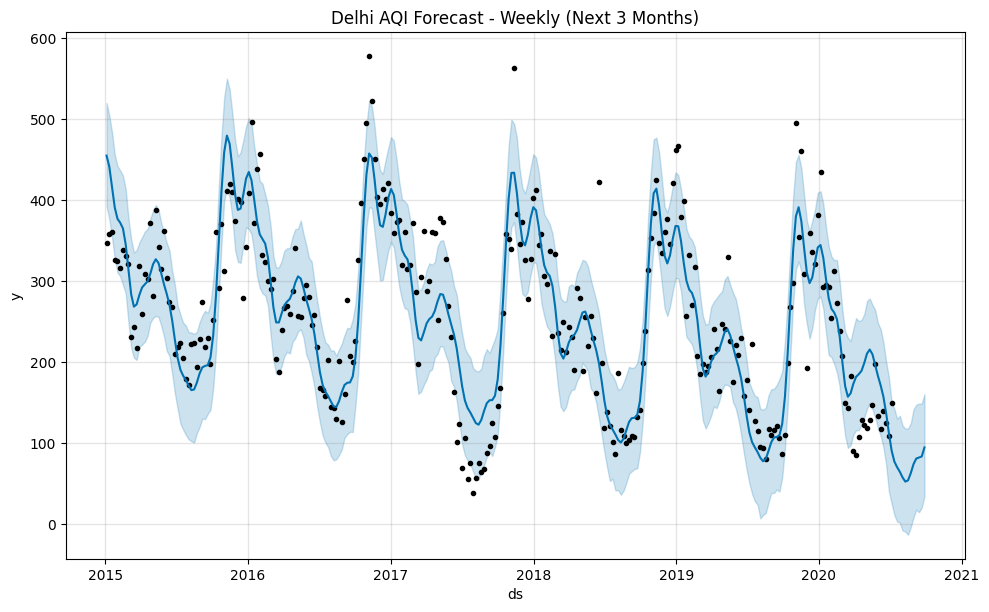

Weekly Model MAE: 39.10 AQI points


In [21]:
# Resample to weekly average - reduces noise significantly
city_df_weekly = city_df.set_index('ds').resample('W').mean().reset_index()

model2 = Prophet(yearly_seasonality=True, daily_seasonality=False)
model2.fit(city_df_weekly)

future2 = model2.make_future_dataframe(periods=12, freq='W')  # 12 weeks ~ 3 months
forecast2 = model2.predict(future2)

model2.plot(forecast2)
plt.title(f'{city_name} AQI Forecast - Weekly (Next 3 Months)')
plt.show()

# Re-check accuracy
actual_vs_pred2 = forecast2[forecast2['ds'].isin(city_df_weekly['ds'])][['ds','yhat']]
merged2 = city_df_weekly.merge(actual_vs_pred2, on='ds')
mae2 = mean_absolute_error(merged2['y'], merged2['yhat'])
print(f"Weekly Model MAE: {mae2:.2f} AQI points")

In [22]:
print(f"Daily model MAE: 52.84 AQI points")
print(f"Weekly model MAE: {mae2:.2f} AQI points")
print(f"Improvement: {((52.84 - mae2) / 52.84 * 100):.1f}%")

Daily model MAE: 52.84 AQI points
Weekly model MAE: 39.10 AQI points
Improvement: 26.0%


In [23]:
# Save the cleaned, city-filtered dataset for Tableau
df.to_csv("aqi_cleaned_for_tableau.csv", index=False)
print("Saved successfully")

Saved successfully


In [24]:
# Save Delhi's forecast so it can be shown in Tableau too
forecast2[['ds','yhat','yhat_lower','yhat_upper']].to_csv("delhi_forecast.csv", index=False)